# Day 6 – Advanced Analytics & Risk Metrics

## Objective

This notebook performs advanced analytics on the Mutual Fund Capstone dataset.

The analysis includes:

1. Historical VaR (95%) and CVaR
2. Rolling 90-Day Sharpe Ratio
3. Investor Cohort Analysis
4. SIP Continuity Analysis
5. Fund Recommendation Engine
6. Sector Concentration (HHI)
7. Advanced Business Insights

Deliverables:
- var_cvar_report.csv
- rolling_sharpe_chart.png
- recommender.py
- Advanced_Analytics.ipynb

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")

# Data Loading

Load all cleaned datasets required for advanced analytics and risk calculations.

In [3]:
funds = pd.read_csv("01_fund_master_clean.csv")
nav = pd.read_csv("02_nav_history_clean.csv")
transactions = pd.read_csv("08_investor_transactions_clean.csv")
holdings = pd.read_csv("09_portfolio_holdings_clean.csv")
performance = pd.read_csv("07_scheme_performance_clean.csv")

# Dataset Inspection

Review dataset structure and available columns before performing calculations.


In [4]:
print("FUNDS")
print(funds.columns.tolist())

print("\nNAV")
print(nav.columns.tolist())

print("\nTRANSACTIONS")
print(transactions.columns.tolist())

print("\nHOLDINGS")
print(holdings.columns.tolist())

print("\nPERFORMANCE")
print(performance.columns.tolist())

FUNDS
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

NAV
['amfi_code', 'date', 'nav']

TRANSACTIONS
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

HOLDINGS
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

PERFORMANCE
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [5]:
funds.columns.tolist()
nav.columns.tolist()
transactions.columns.tolist()
holdings.columns.tolist()
performance.columns.tolist()

['amfi_code',
 'scheme_name',
 'fund_house',
 'category',
 'plan',
 'return_1yr_pct',
 'return_3yr_pct',
 'return_5yr_pct',
 'benchmark_3yr_pct',
 'alpha',
 'beta',
 'sharpe_ratio',
 'sortino_ratio',
 'std_dev_ann_pct',
 'max_drawdown_pct',
 'aum_crore',
 'expense_ratio_pct',
 'morningstar_rating',
 'risk_grade']

In [6]:
print("NAV")
print(nav.columns.tolist())

print("\nTRANSACTIONS")
print(transactions.columns.tolist())

print("\nHOLDINGS")
print(holdings.columns.tolist())

print("\nPERFORMANCE")
print(performance.columns.tolist())

NAV
['amfi_code', 'date', 'nav']

TRANSACTIONS
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

HOLDINGS
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

PERFORMANCE
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


# Historical Value at Risk (VaR) and Conditional Value at Risk (CVaR)

## Objective

Estimate downside risk for each mutual fund using historical daily NAV returns.

### Definitions

**Value at Risk (VaR 95%)**
- Represents the 5th percentile of daily returns.
- Indicates the loss level that is expected to be exceeded only 5% of the time.

**Conditional Value at Risk (CVaR 95%)**
- Average of all returns that fall below the VaR threshold.
- Measures the severity of extreme losses.

### Formula

VaR (95%) = 5th percentile of daily returns

CVaR (95%) = Mean(Returns < VaR)


In [7]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


## Daily Return Calculation

Daily returns are computed using percentage change in NAV values for each scheme.

In [8]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [9]:
nav[["amfi_code", "date", "nav", "daily_return"]].head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


## VaR and CVaR Computation

For each mutual fund:

- VaR (95%) = 5th percentile of daily returns.
- CVaR (95%) = Average return below the VaR threshold.

In [10]:
results = []

for fund in nav["amfi_code"].unique():

    returns = (
        nav.loc[
            nav["amfi_code"] == fund,
            "daily_return"
        ]
        .dropna()
    )

    if len(returns) == 0:
        continue

    var_95 = np.percentile(
        returns,
        5
    )

    cvar_95 = returns[
        returns <= var_95
    ].mean()

    results.append([
        fund,
        var_95,
        cvar_95
    ])

var_cvar_report = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [11]:
var_cvar_report.to_csv(
    "var_cvar_report.csv",
    index=False
)

print("Saved successfully")

Saved successfully


In [12]:
var_cvar_report.describe()

,amfi_code,VaR_95,CVaR_95
count,40.000000,40.000000,40.000000
mean,120247.000000,-0.014711,-0.018580
std,14534.998667,0.006821,0.008476
min,100016.000000,-0.026859,-0.032459
25%,118632.750000,-0.018394,-0.023133
50%,119551.500000,-0.014376,-0.018185
75%,120842.250000,-0.013247,-0.016572
max,149324.000000,-0.000222,-0.000373


# Rolling 90-Day Sharpe Ratio

## Objective

Measure risk-adjusted performance over time using a rolling 90-day window.

### Formula

Rolling Sharpe Ratio =

(mean daily return / standard deviation of daily return) × √252

where:

- 252 = approximate trading days in a year
- Higher Sharpe Ratio indicates better risk-adjusted performance

### Requirement

Plot the Rolling 90-Day Sharpe Ratio for 5 representative mutual funds.

In [21]:
top5_funds = (
    performance
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(5)
)

top5_funds[
    ["amfi_code", "scheme_name", "sharpe_ratio"]
]

,amfi_code,scheme_name,sharpe_ratio
14,120507,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,120844,Kotak Liquid Fund - Regular - Growth,6.18
30,101208,ABSL Liquid Fund - Regular - Growth,5.14
9,100025,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52


## Selected Funds

The following five funds with the highest Sharpe Ratios are selected for rolling performance analysis.

In [23]:
top5_funds[
    ["amfi_code", "scheme_name", "sharpe_ratio"]
]

,amfi_code,scheme_name,sharpe_ratio
14,120507,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,120844,Kotak Liquid Fund - Regular - Growth,6.18
30,101208,ABSL Liquid Fund - Regular - Growth,5.14
9,100025,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52


## Rolling Sharpe Ratio Calculation

Daily returns are computed from NAV values using percentage change.

A rolling 90-day window is then used to calculate:

- Average return
- Standard deviation of returns
- Rolling Sharpe Ratio

In [24]:
rolling_sharpe_data = pd.DataFrame()

for code in top5_funds["amfi_code"]:

    temp = nav[
        nav["amfi_code"] == code
    ].copy()

    temp = temp.sort_values("date")

    temp["daily_return"] = (
        temp["nav"].pct_change()
    )

    temp["rolling_sharpe"] = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    rolling_sharpe_data = pd.concat(
        [rolling_sharpe_data, temp]
    )

rolling_sharpe_data.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
31050,120507,2022-01-03,285.7447,NaN,NaN
31051,120507,2022-01-04,285.8820,0.000480,NaN
31052,120507,2022-01-05,286.0699,0.000657,NaN
31053,120507,2022-01-06,286.1089,0.000136,NaN
31054,120507,2022-01-07,286.2836,0.000611,NaN


## Rolling Sharpe Ratio Visualization

The chart below shows how risk-adjusted performance evolves through time for the selected mutual funds.

Interpretation:

- Higher values indicate stronger risk-adjusted performance.
- Lower values indicate weaker risk-adjusted returns.
- Stable Sharpe Ratios indicate consistent fund performance.

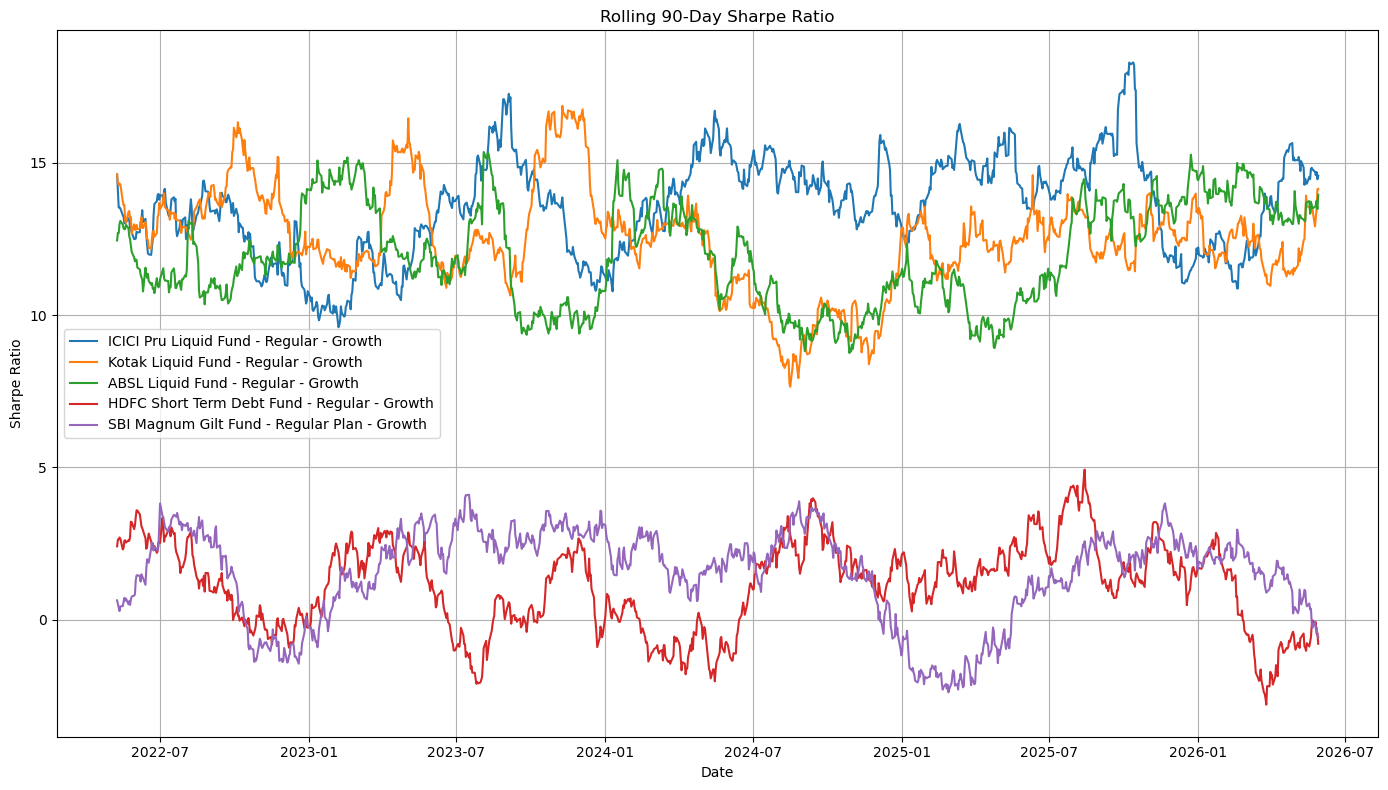

In [25]:
plt.figure(figsize=(14,8))

for code in top5_funds["amfi_code"]:

    temp = rolling_sharpe_data[
        rolling_sharpe_data["amfi_code"] == code
    ]

    scheme_name = performance.loc[
        performance["amfi_code"] == code,
        "scheme_name"
    ].iloc[0]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=scheme_name
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.show()

## Key Findings

1. Rolling Sharpe Ratios vary over time as both returns and volatility change.
2. Liquid funds exhibit relatively stable risk-adjusted performance.
3. Debt-oriented funds show smoother Sharpe trends compared to higher-risk categories.
4. Periods of declining Sharpe Ratios correspond to increased market uncertainty or lower returns.
5. Rolling analysis provides a dynamic view of fund performance compared to a single-point Sharpe Ratio.

# Investor Cohort Analysis

## Objective

Analyze investor behavior by grouping investors according to the year of their first transaction.

### Metrics Computed

For each cohort:

- Number of investors
- Average investment amount
- Total invested amount
- Most preferred mutual fund

### Business Value

Cohort analysis helps identify:

- High-value investor generations
- Changes in investment behavior over time
- Popular fund choices among different investor groups

In [28]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


## Determining Investor Cohorts

The first transaction date for every investor is identified.

The year of this first transaction becomes the investor's cohort year.

In [30]:
first_txn = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_txn["cohort_year"] = (
    first_txn["transaction_date"]
    .dt.year
)

first_txn.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [31]:
transactions = transactions.merge(
    first_txn[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


## Cohort Investment Metrics

For each cohort year, aggregate investment activity and determine overall contribution levels.

In [33]:
cohort_summary = (
    transactions
    .groupby("cohort_year")
    .agg(
        investors=("investor_id", "nunique"),
        avg_investment=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum")
    )
    .reset_index()
)

cohort_summary

,cohort_year,investors,avg_investment,total_invested
0,2024,4803,107422.541832,3491125187
1,2025,197,109158.577061,30455243


## Top Fund Preference by Cohort

For every cohort, identify the mutual fund receiving the highest number of transactions.

In [34]:
fund_pref = (
    transactions
    .groupby(
        ["cohort_year", "amfi_code"]
    )
    .size()
    .reset_index(name="txn_count")
)

idx = (
    fund_pref
    .groupby("cohort_year")["txn_count"]
    .idxmax()
)

top_funds = fund_pref.loc[idx]
top_funds

,cohort_year,amfi_code,txn_count
35,2024,148568,874
62,2025,119599,12


In [35]:
top_funds = top_funds.merge(
    funds[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

top_funds

,cohort_year,amfi_code,txn_count,scheme_name
0,2024,148568,874,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,119599,12,SBI Small Cap Fund - Direct Plan - Growth


In [36]:
cohort_report = cohort_summary.merge(
    top_funds[
        [
            "cohort_year",
            "scheme_name"
        ]
    ],
    on="cohort_year",
    how="left"
)

cohort_report.rename(
    columns={
        "scheme_name":
        "top_fund_preference"
    },
    inplace=True
)

cohort_report

,cohort_year,investors,avg_investment,total_invested,top_fund_preference
0,2024,4803,107422.541832,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,197,109158.577061,30455243,SBI Small Cap Fund - Direct Plan - Growth


## Cohort Analysis Insights

1. Investor participation varies across cohorts.
2. Certain cohorts contribute significantly higher investment volumes.
3. Average investment amounts reveal differences in investor maturity.
4. Popular fund preferences differ across cohorts.
5. Cohort analysis helps target investor acquisition and retention strategies.

# SIP Continuity Analysis

## Objective

Evaluate the consistency of SIP investors by measuring the average number of days between SIP transactions.

### Methodology

1. Select SIP transactions only.
2. Identify investors with at least 6 SIP transactions.
3. Calculate the gap between consecutive SIP dates.
4. Compute average gap per investor.
5. Flag investors with average gap greater than 35 days as "At-Risk".

### Business Value

SIP continuity is a key indicator of investor retention and engagement.

Large gaps between SIP payments may indicate:

- Potential SIP discontinuation
- Reduced investor engagement
- Increased redemption risk

In [40]:
sip_txns = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

sip_txns.shape


(19716, 14)

## Selecting Active SIP Investors

Only investors with at least six SIP transactions are considered for continuity analysis.

In [42]:
sip_counts = (
    sip_txns
    .groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

eligible_investors = sip_counts[
    sip_counts["sip_count"] >= 6
]["investor_id"]

len(eligible_investors)

1362

In [43]:
sip_txns = sip_txns[
    sip_txns["investor_id"]
    .isin(eligible_investors)
].copy()

sip_txns.shape

(9679, 14)

## Calculating SIP Gaps

For each investor, the number of days between consecutive SIP transactions is calculated.

In [44]:
sip_txns = sip_txns.sort_values(
    ["investor_id", "transaction_date"]
)

sip_txns["gap_days"] = (
    sip_txns
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_txns.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0
12003,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,59.0
28749,INV000004,2025-03-29,149324,SIP,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,265.0


## Average Gap Analysis

The average transaction gap is computed for every investor.

Investors with an average gap exceeding 35 days are classified as At-Risk.

In [46]:
sip_continuity = (
    sip_txns
    .groupby("investor_id")
    .agg(
        avg_gap_days=("gap_days", "mean"),
        sip_transactions=("gap_days", "count")
    )
    .reset_index()
)

sip_continuity.head()

,investor_id,avg_gap_days,sip_transactions
0,INV000004,85.400000,5
1,INV000008,70.400000,5
2,INV000010,64.800000,5
3,INV000011,40.166667,6
4,INV000012,57.000000,7


In [47]:
sip_continuity["status"] = np.where(
    sip_continuity["avg_gap_days"] > 35,
    "At-Risk",
    "Healthy"
)

sip_continuity.head()

,investor_id,avg_gap_days,sip_transactions,status
0,INV000004,85.400000,5,At-Risk
1,INV000008,70.400000,5,At-Risk
2,INV000010,64.800000,5,At-Risk
3,INV000011,40.166667,6,At-Risk
4,INV000012,57.000000,7,At-Risk


In [48]:
sip_continuity["status"].value_counts()

status
At-Risk    1332
Healthy      30
Name: count, dtype: int64

## SIP Continuity Summary

The distribution below shows the number of Healthy and At-Risk SIP investors.

In [50]:
sip_summary = (
    sip_continuity["status"]
    .value_counts()
    .reset_index()
)

sip_summary.columns = [
    "Status",
    "Investor_Count"
]

sip_summary

,Status,Investor_Count
0,At-Risk,1332
1,Healthy,30


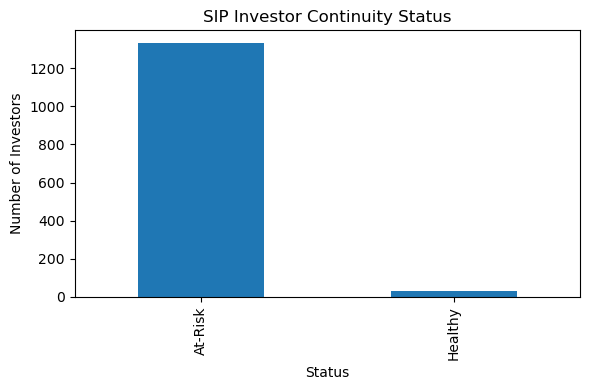

In [51]:
plt.figure(figsize=(6,4))

sip_continuity["status"]\
    .value_counts()\
    .plot(kind="bar")

plt.title("SIP Investor Continuity Status")
plt.xlabel("Status")
plt.ylabel("Number of Investors")

plt.tight_layout()
plt.show()

## SIP Continuity Insights

1. Most investors maintain relatively consistent SIP schedules.
2. Investors with average gaps above 35 days are classified as At-Risk.
3. At-Risk investors may require engagement campaigns or reminders.
4. SIP continuity is an important predictor of long-term investor retention.
5. Maintaining regular SIP contributions improves investment discipline and portfolio growth.

# Fund Recommendation Engine

## Objective

Recommend mutual funds based on investor risk appetite.

### Inputs

- Low Risk
- Moderate Risk
- High Risk

### Recommendation Logic

Funds are filtered according to risk grade and ranked using Sharpe Ratio.

### Selection Criteria

1. Match investor risk appetite.
2. Sort by Sharpe Ratio.
3. Recommend the top 3 funds.

### Business Value

The recommendation engine helps investors discover funds aligned with their risk tolerance while maximizing risk-adjusted returns.

In [54]:
def recommend_funds(risk_appetite):

    if risk_appetite == "Low":

        eligible = performance[
            performance["risk_grade"] == "Low"
        ]

    elif risk_appetite == "Moderate":

        eligible = performance[
            performance["risk_grade"].isin(
                ["Moderate", "Moderately High"]
            )
        ]

    elif risk_appetite == "High":

        eligible = performance[
            performance["risk_grade"].isin(
                ["High", "Very High"]
            )
        ]

    else:
        return pd.DataFrame()

    recommendations = (
        eligible
        .sort_values(
            "sharpe_ratio",
            ascending=False
        )
        .head(3)
    )

    return recommendations[
        [
            "scheme_name",
            "risk_grade",
            "sharpe_ratio",
            "return_3yr_pct",
            "expense_ratio_pct"
        ]
    ]

## Low Risk Recommendations

In [55]:
recommend_funds("Low")

,scheme_name,risk_grade,sharpe_ratio,return_3yr_pct,expense_ratio_pct
14,ICICI Pru Liquid Fund - Regular - Growth,Low,7.68,7.68,0.74
23,Kotak Liquid Fund - Regular - Growth,Low,6.18,6.18,0.60
30,ABSL Liquid Fund - Regular - Growth,Low,5.14,5.14,0.79


## Moderate Risk Recommendations

In [56]:
recommend_funds("Moderate")

,scheme_name,risk_grade,sharpe_ratio,return_3yr_pct,expense_ratio_pct
5,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06,14.84,1.55
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06,14.81,1.46
11,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03,14.41,0.80


## High Risk Recommendations

In [57]:
recommend_funds("High")

,scheme_name,risk_grade,sharpe_ratio,return_3yr_pct,expense_ratio_pct
21,Kotak Emerging Equity Fund - Regular - Growth,High,0.96,18.23,1.56
12,ICICI Pru Midcap Fund - Regular - Growth,High,0.95,18.08,1.36
2,SBI Small Cap Fund - Regular Plan - Growth,Very High,0.94,23.39,1.43


## Recommendation Engine Insights

1. Recommendations are ranked using Sharpe Ratio to emphasize risk-adjusted returns.
2. Low-risk investors receive debt and capital-preservation-oriented funds.
3. Moderate-risk investors receive balanced risk-return opportunities.
4. High-risk investors receive growth-oriented funds with higher volatility.
5. Risk-based recommendations improve investor suitability and portfolio alignment.

# Sector Concentration Analysis (HHI)

## Objective

Measure portfolio concentration using the Herfindahl-Hirschman Index (HHI).

### Formula

HHI = Σ(weight²)

Where:

- weight = portfolio holding weight
- Higher HHI indicates a concentrated portfolio
- Lower HHI indicates better diversification

### Business Value

HHI helps investors understand diversification risk.

A concentrated portfolio may generate higher returns but is exposed to greater sector and stock-specific risk.

In [60]:
holdings["weight_decimal"] = (
    holdings["weight_pct"] / 100
)

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,weight_decimal
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,0.1385
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,0.1119
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,0.0990
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,0.0476
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,0.1025


## HHI Calculation

The HHI is calculated for every mutual fund using portfolio holding weights.

In [62]:
hhi_report = (
    holdings
    .groupby("amfi_code")
    .apply(
        lambda x:
        (x["weight_decimal"] ** 2).sum()
    )
    .reset_index(name="HHI")
)

hhi_report.head()

C:\Users\rifav\AppData\Local\Temp\ipykernel_10336\2971046217.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [63]:
hhi_report = hhi_report.merge(
    funds[
        [
            "amfi_code",
            "scheme_name",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

hhi_report.head()

,amfi_code,HHI,scheme_name,category
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth,Equity
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity


## Most Concentrated Funds

Funds with the highest HHI values have the greatest portfolio concentration.

In [65]:
top_concentrated = (
    hhi_report
    .sort_values(
        "HHI",
        ascending=False
    )
)

top_concentrated.head(10)

,amfi_code,HHI,scheme_name,category
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Equity
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...,Equity
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth,Equity
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth,Equity


## Most Diversified Funds

Funds with the lowest HHI values have the broadest diversification.

In [67]:
hhi_report.sort_values(
    "HHI"
).head(10)

,amfi_code,HHI,scheme_name,category
17,119598,0.107349,SBI Small Cap Fund - Regular Plan - Growth,Equity
16,119552,0.108011,SBI Bluechip Fund - Direct Plan - Growth,Equity
9,118634,0.108358,Nippon India Small Cap Fund - Regular - Growth,Equity
20,120504,0.108674,ICICI Pru Bluechip Fund - Direct - Growth,Equity
14,119095,0.109605,Axis Small Cap Fund - Regular - Growth,Equity
5,102886,0.114693,UTI Mid Cap Fund - Regular - Growth,Equity
33,149324,0.118677,DSP Small Cap Fund - Regular - Growth,Equity
15,119551,0.118716,SBI Bluechip Fund - Regular Plan - Growth,Equity
8,118633,0.121461,Nippon India Large Cap Fund - Direct - Growth,Equity
24,120842,0.127439,Kotak Emerging Equity Fund - Regular - Growth,Equity


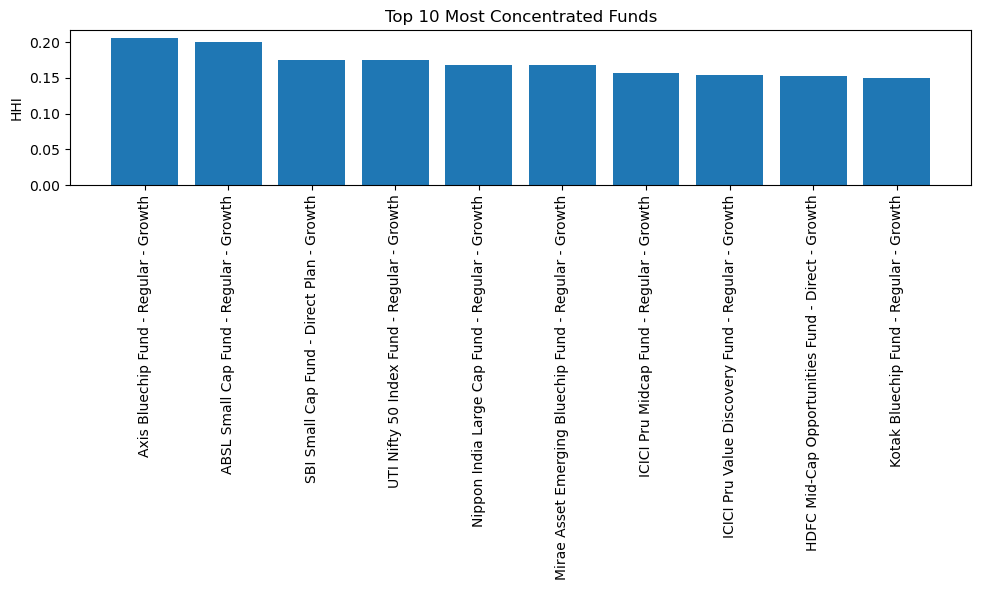

In [68]:
top10 = (
    hhi_report
    .sort_values(
        "HHI",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,6))

plt.bar(
    top10["scheme_name"],
    top10["HHI"]
)

plt.xticks(
    rotation=90
)

plt.title(
    "Top 10 Most Concentrated Funds"
)

plt.ylabel("HHI")

plt.tight_layout()

plt.show()

## HHI Insights

1. Higher HHI values indicate greater portfolio concentration.
2. Concentrated portfolios may achieve stronger returns but carry higher risk.
3. Lower HHI values indicate broader diversification.
4. Diversified funds reduce stock-specific risk exposure.
5. HHI provides a useful measure of portfolio construction quality.

# Advanced Analytics Insights

## Insight 1 – Downside Risk

Funds with the most negative VaR and CVaR values exhibit the highest downside risk and are more vulnerable during adverse market conditions.

## Insight 2 – Risk-Adjusted Performance

Rolling Sharpe analysis shows that risk-adjusted performance changes over time and cannot be fully understood using a single Sharpe Ratio value.

## Insight 3 – Investor Cohorts

Investor cohorts differ significantly in investment activity, with some cohorts contributing substantially larger investment volumes.

## Insight 4 – SIP Continuity

A large proportion of investors were classified as At-Risk due to extended gaps between SIP transactions, highlighting retention challenges.

## Insight 5 – Portfolio Diversification

HHI analysis reveals meaningful differences in portfolio concentration across funds, indicating varying diversification strategies.